In [64]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

# Configure plotting aesthetics
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (12, 6)

# 1. Load Datasets
# Loading CMIP6 NorCPM1 data for 1pctCO2 experiment
ds_cVeg = xr.open_dataset("../CMIP6 data/NorCPM1/cVeg_Lmon_NorCPM1_1pctCO2_r1i1p1f1_gn_000102-016412.nc")
ds_tas = xr.open_dataset("../CMIP6 data/NorCPM1/tas_Amon_NorCPM1_1pctCO2_r1i1p1f1_gn_000101-016412.nc")

# 2. Process Surface Air Temperature (tas) to obtain GMST Anomaly
# Resample to annual mean to remove seasonal cycles
ds_tas_annual = ds_tas['tas'].resample(time='YE').mean('time')

# Calculate area-weighted global mean
weights = np.cos(np.deg2rad(ds_tas_annual.lat))
gmst_annual = ds_tas_annual.weighted(weights).mean(('lat', 'lon'))

# Define baseline as the mean of the first 20 years and calculate anomaly
baseline = gmst_annual.isel(time=slice(0, 20)).mean('time')
delta_T_annual = gmst_annual - baseline

# 3. Preprocess Vegetation Carbon (cVeg)
# Resample to annual mean to match temperature data
cVeg_annual = ds_cVeg['cVeg'].resample(time='YE').mean('time')


# Map GMST anomaly
cVeg_annual.coords['GMST'] = delta_T_annual
cVeg_annual = cVeg_annual.swap_dims({'time': 'GMST'})

# Cutting only Amazon area
# Latitude -15~5, Longtitude 280~310
amazon_cVeg = cVeg_annual.sel(lat=slice(-15, 5), lon=slice(280, 320))

# 4. Prepare data for TOAD - renaming the value
ds_for_toad = amazon_cVeg.rename({'lat': 'y', 'lon': 'x'})

# Keep only the target variable 'cVeg' and sort by GMST
ds_for_toad = ds_for_toad.to_dataset(name='cVeg')
ds_for_toad = ds_for_toad.sortby('GMST')

print("Final variable list:", ds_for_toad.data_vars)
print("Final dimension structure:", ds_for_toad.dims)

# 5. Initialize TOAD
# Add path to the toad-main directory
toad_path = Path.cwd().parent / "toad-main"
if str(toad_path) not in sys.path:
    sys.path.append(str(toad_path))

from toad.core import TOAD

# Initialize TOAD with the prepared dataset
td = TOAD(ds_for_toad, time_dim="GMST")



Final variable list: Data variables:
    cVeg     (GMST, y, x) float32 123kB 0.0 0.0 1.473 2.573 ... 0.0 0.0 0.0 0.0
Final dimension structure: FrozenMappingWarningOnValuesAccess({'y': 11, 'x': 17, 'GMST': 164})


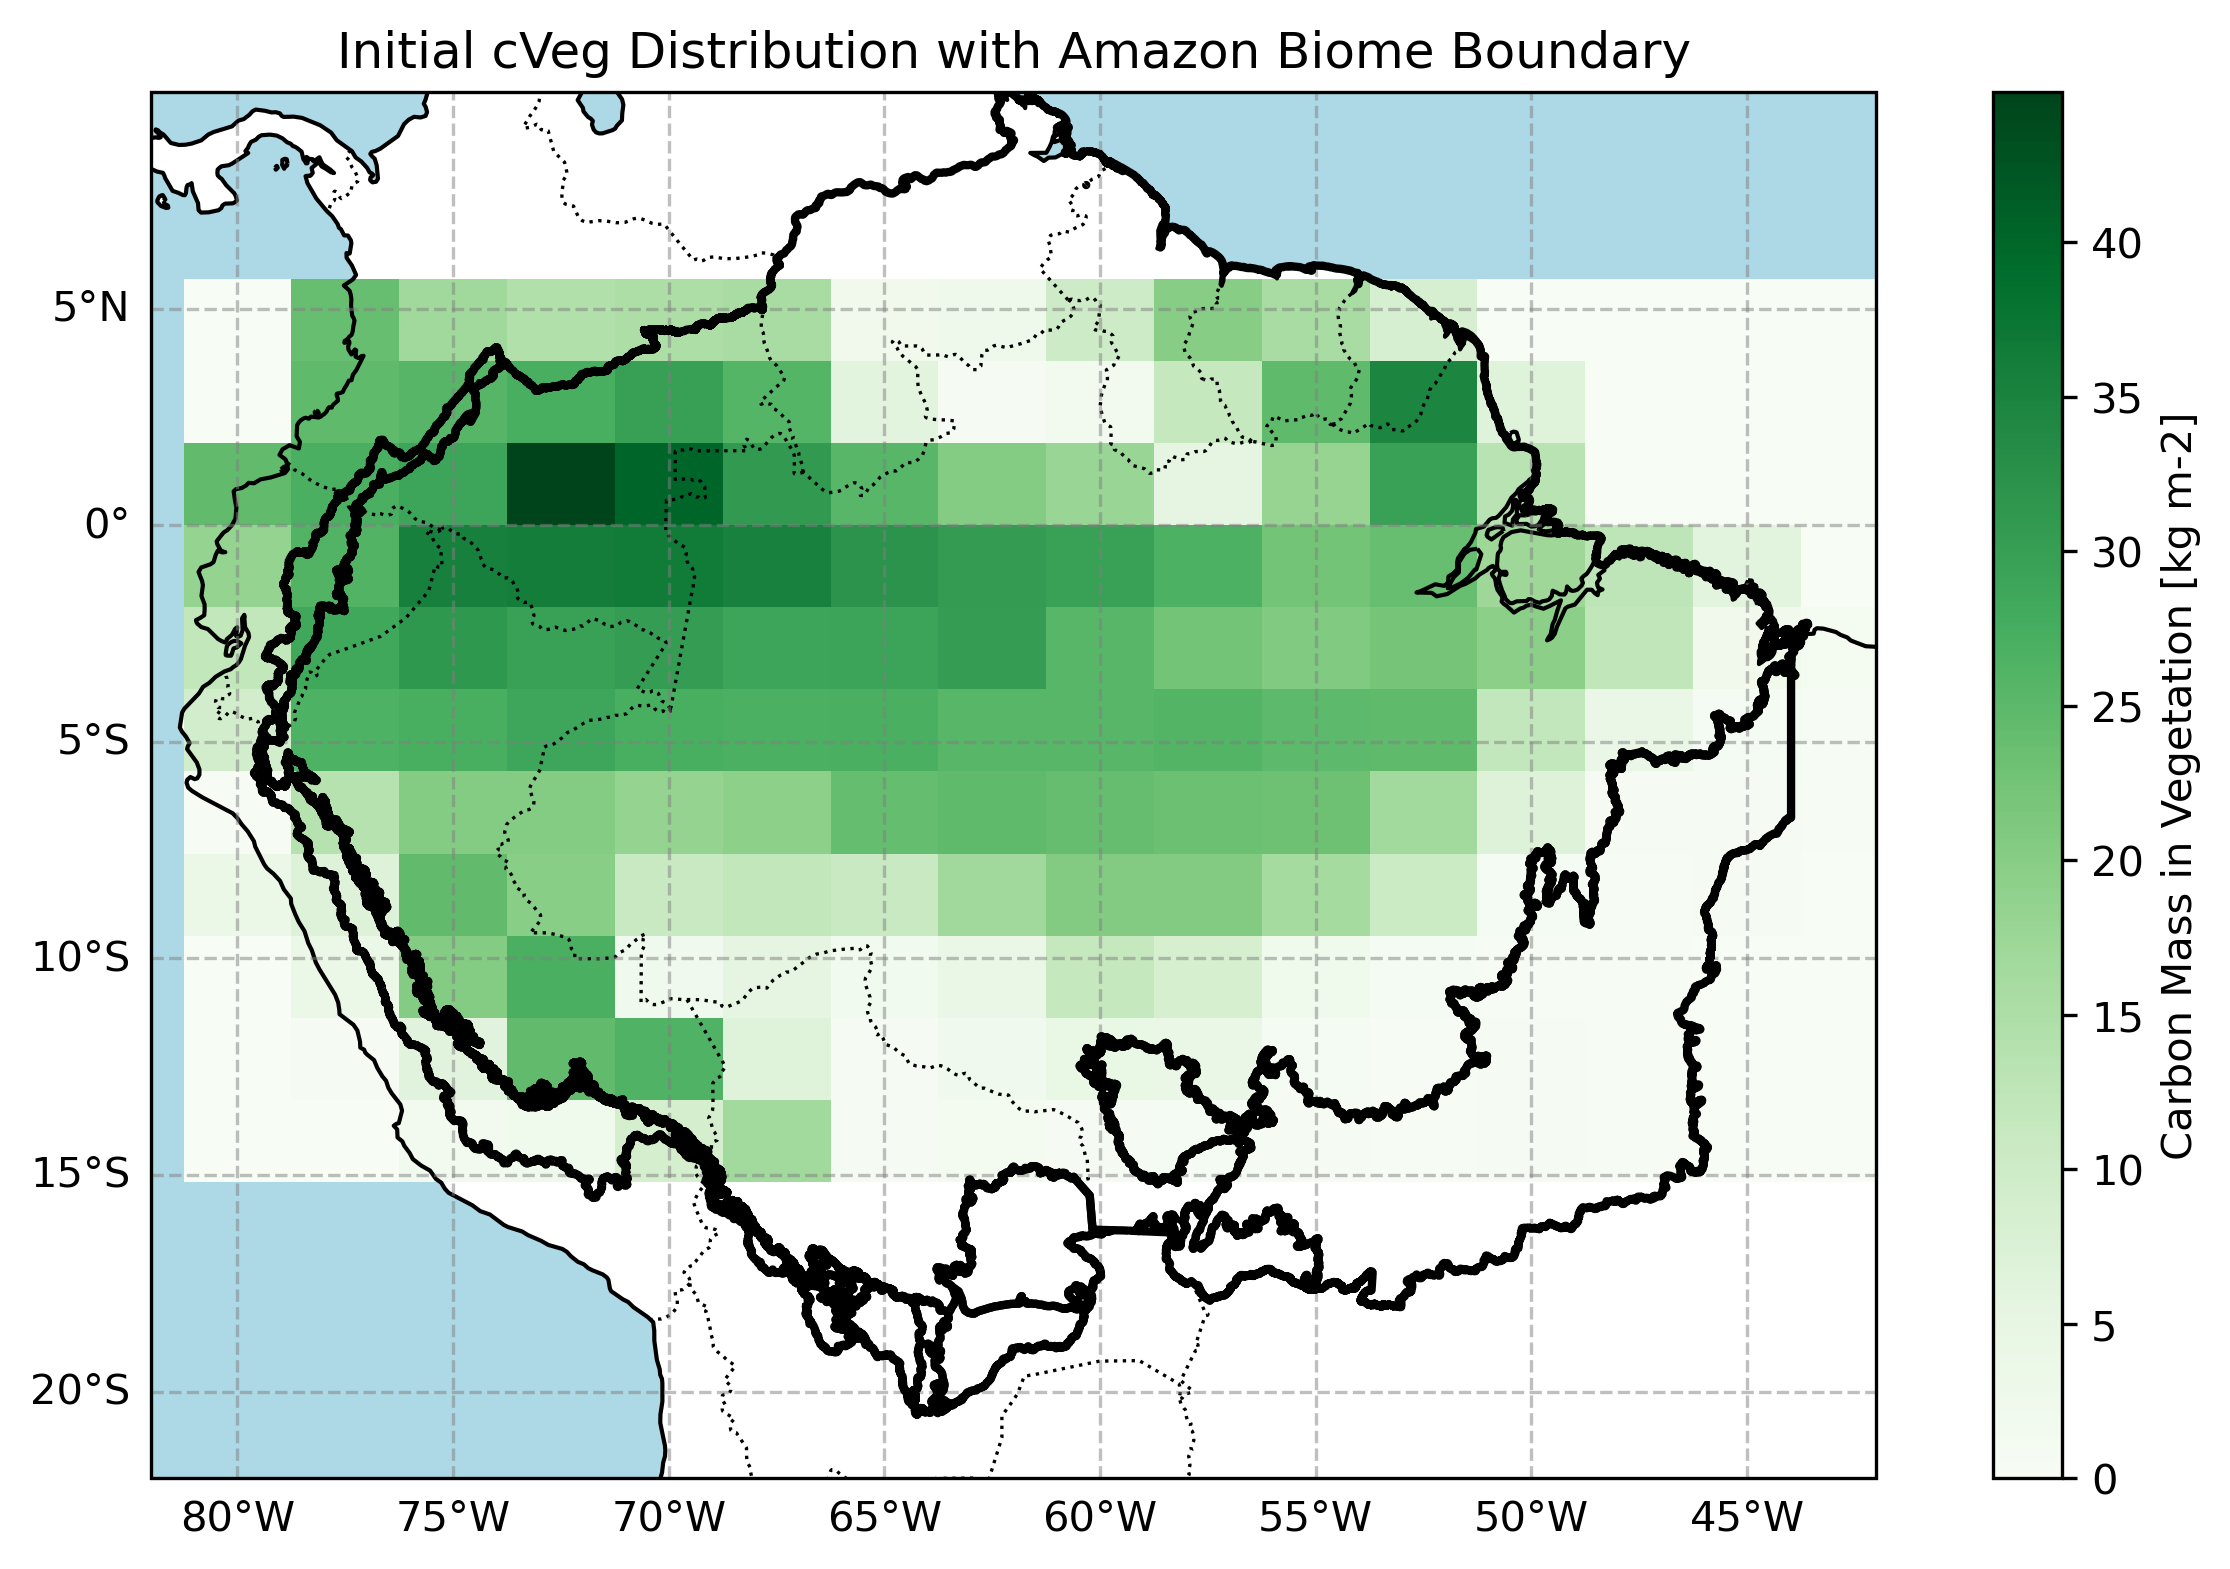

In [79]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# 1. Load data and Shapefile
amazon_subset = ds_for_toad['cVeg']
amazon_boundary = gpd.read_file('../data/Biomas_2025/Biomas.shp')

# Ensure the Shapefile uses the same WGS84 coordinate system (EPSG:4326) as the climate data
if amazon_boundary.crs is not None and amazon_boundary.crs.to_string() != 'EPSG:4326':
    amazon_boundary = amazon_boundary.to_crs(epsg=4326)

# ---------------------------------------------------------
# 1. Initial cVeg Distribution with Amazon Biome Boundary
# ---------------------------------------------------------
fig1 = plt.figure(figsize=(10, 6))
ax1 = plt.axes(projection=ccrs.PlateCarree())

# Set background features (zorder=0)
ax1.add_feature(cfeature.LAND, facecolor='white', zorder=0)
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)

# Plot the cVeg data (zorder=1)
amazon_subset.isel(GMST=0).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='Greens',
    zorder=1, 
    cbar_kwargs={'label': 'Carbon Mass in Vegetation [kg m-2]'}
)

# Add standard coastlines and country borders (zorder=2)
ax1.add_feature(cfeature.COASTLINE, linewidth=1, zorder=2)
ax1.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black', linestyle=':', zorder=2)

# Overlay the WWF/RAISG Amazon Biome Boundary (zorder=3, thick solid line)
amazon_boundary.plot(
    ax=ax1, 
    edgecolor='black',  # Distinct color for the biome boundary
    facecolor='none', 
    linewidth=2.0, 
    zorder=3
)

# Adjust extent and gridlines
ax1.set_extent([-82, -42, -22, 10], crs=ccrs.PlateCarree())
gl1 = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5, zorder=4)
gl1.top_labels = False 
gl1.right_labels = False 

plt.title("Initial cVeg Distribution with Amazon Biome Boundary")
plt.show()


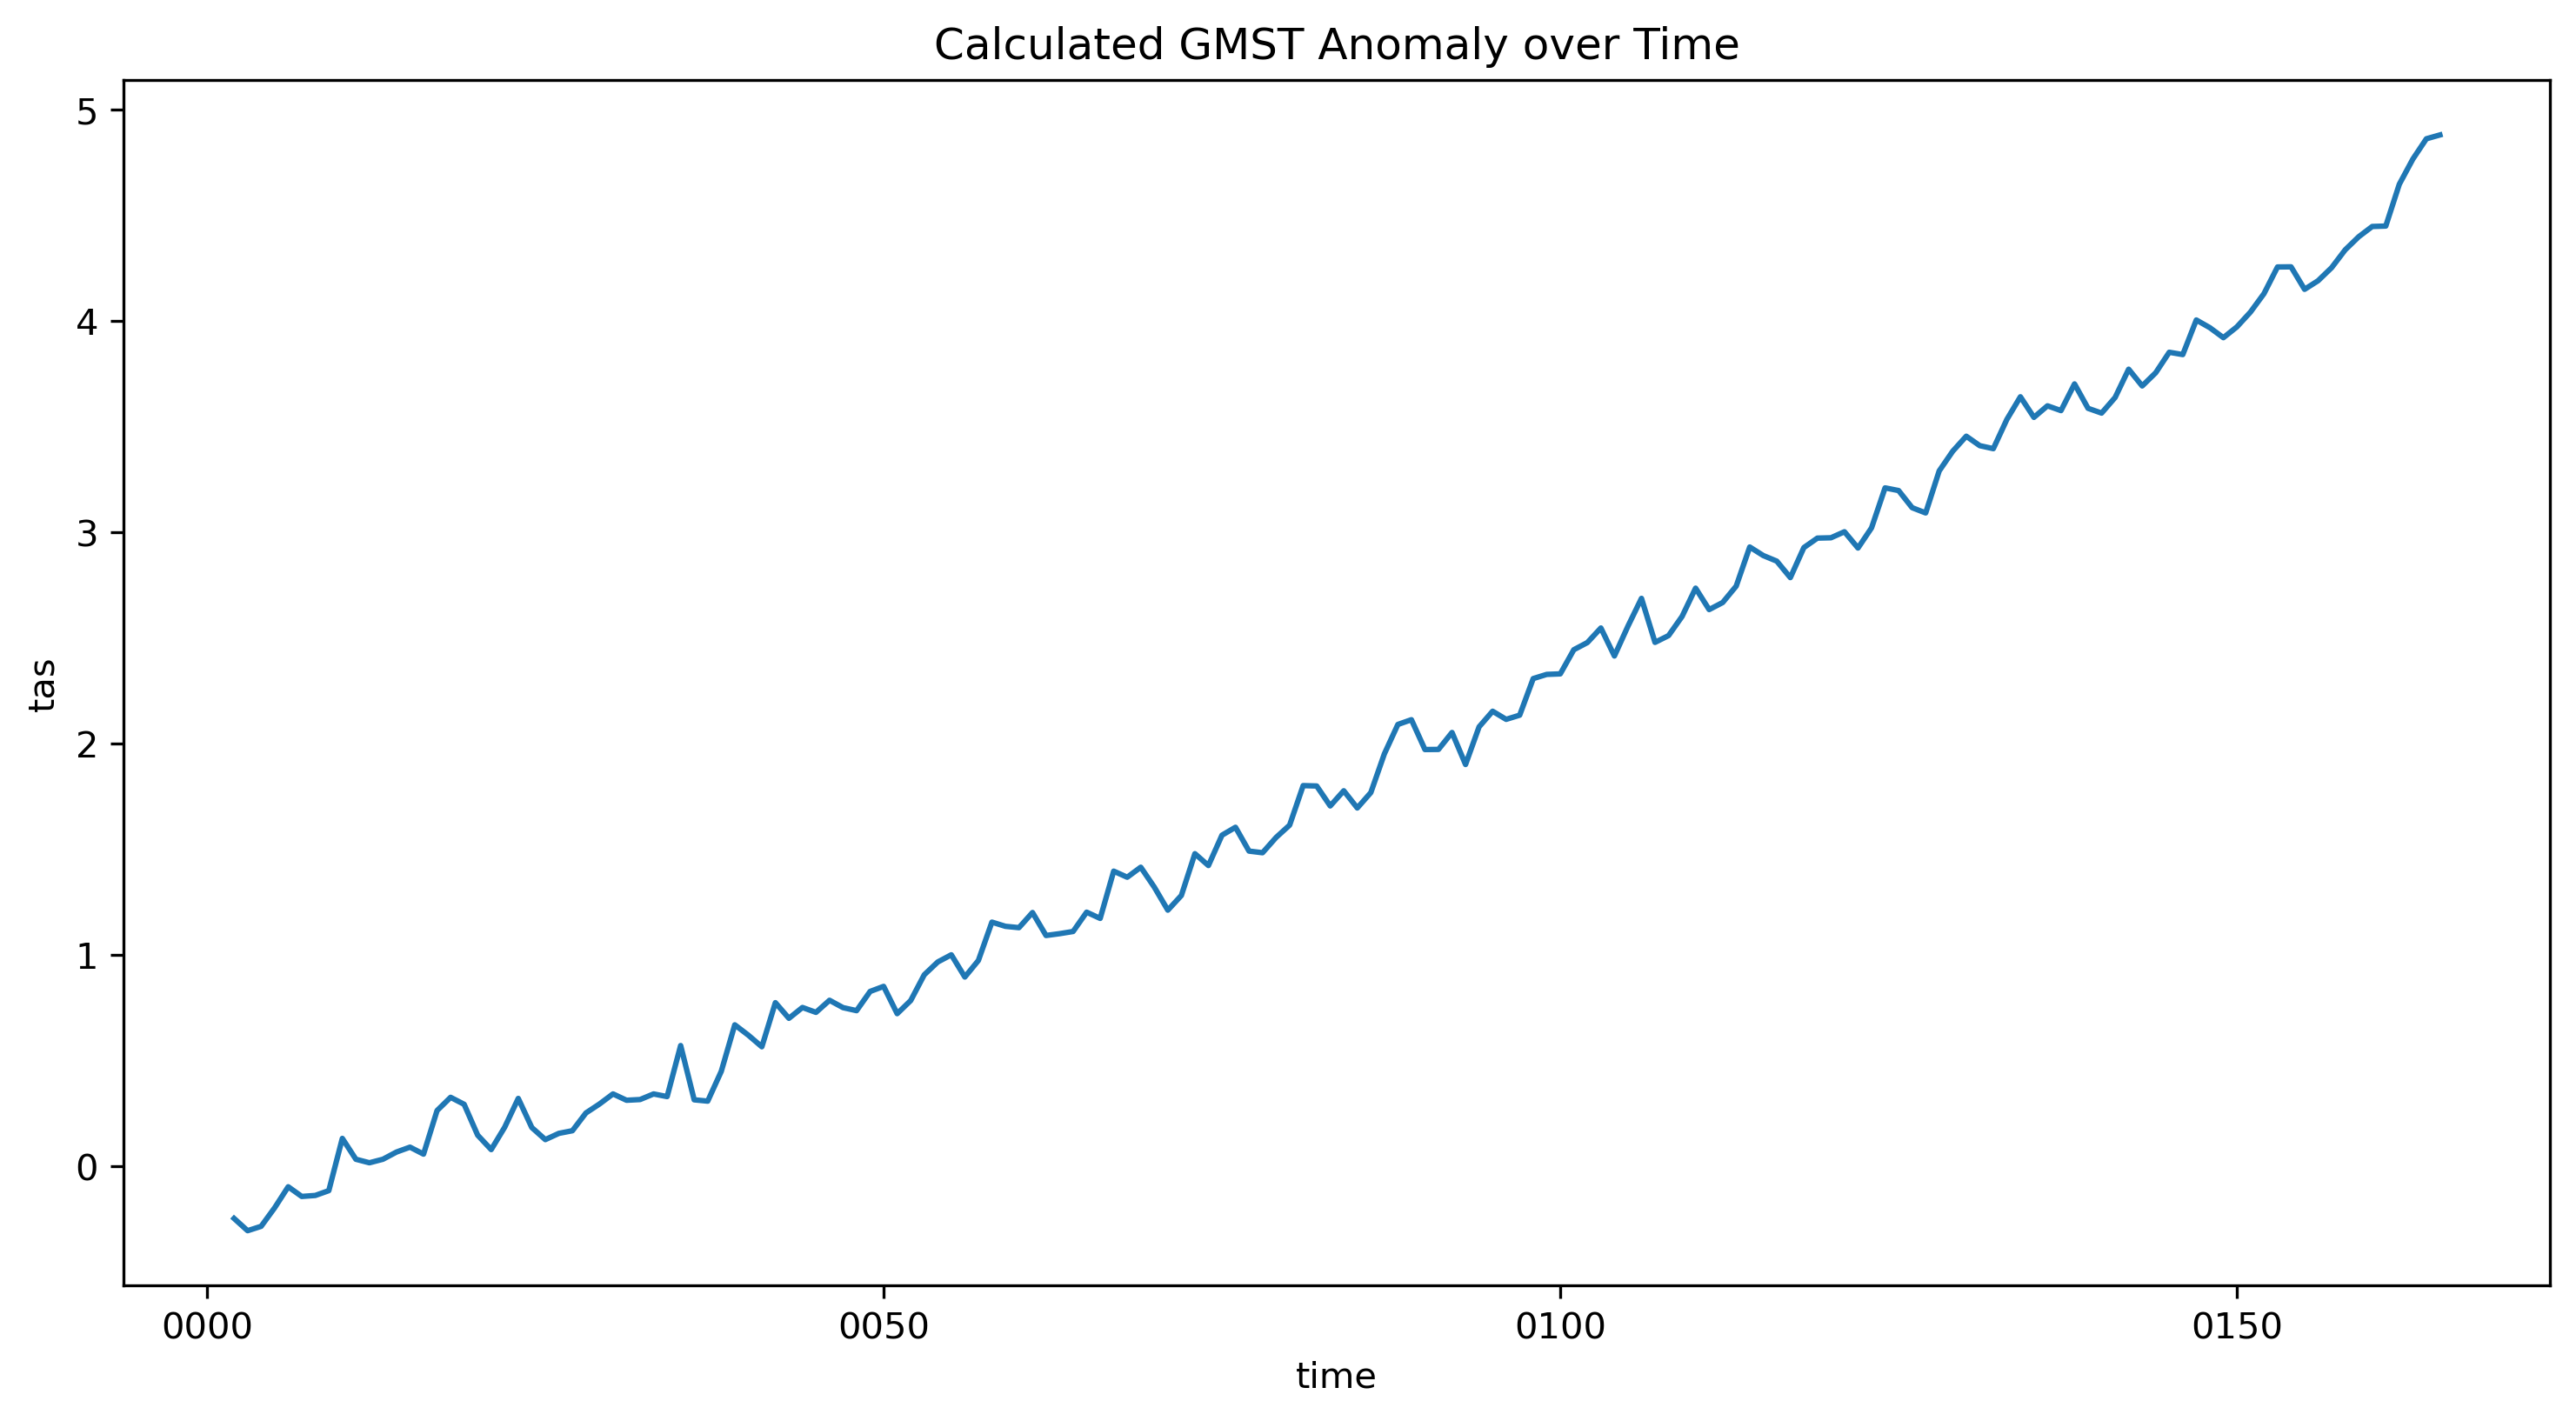

In [66]:
# Global Mean Surface Temperature
plt.figure()
delta_T_annual.plot()
plt.title("Calculated GMST Anomaly over Time")
plt.show()

In [67]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var="cVeg", method=ASDETECT(timescale=(0.5, 1.0)))

# ~12 seconds

Shift detection (187 grid cells in 3 blocks):   0%|          | 0/3 [00:00<?, ?it/s]

INFO: New shifts variable cVeg_dts: min/mean/max=-0.840/0.000/0.800 using 165 grid cells. Skipped 11.8% grid cells: 0 NaN, 22 constant.


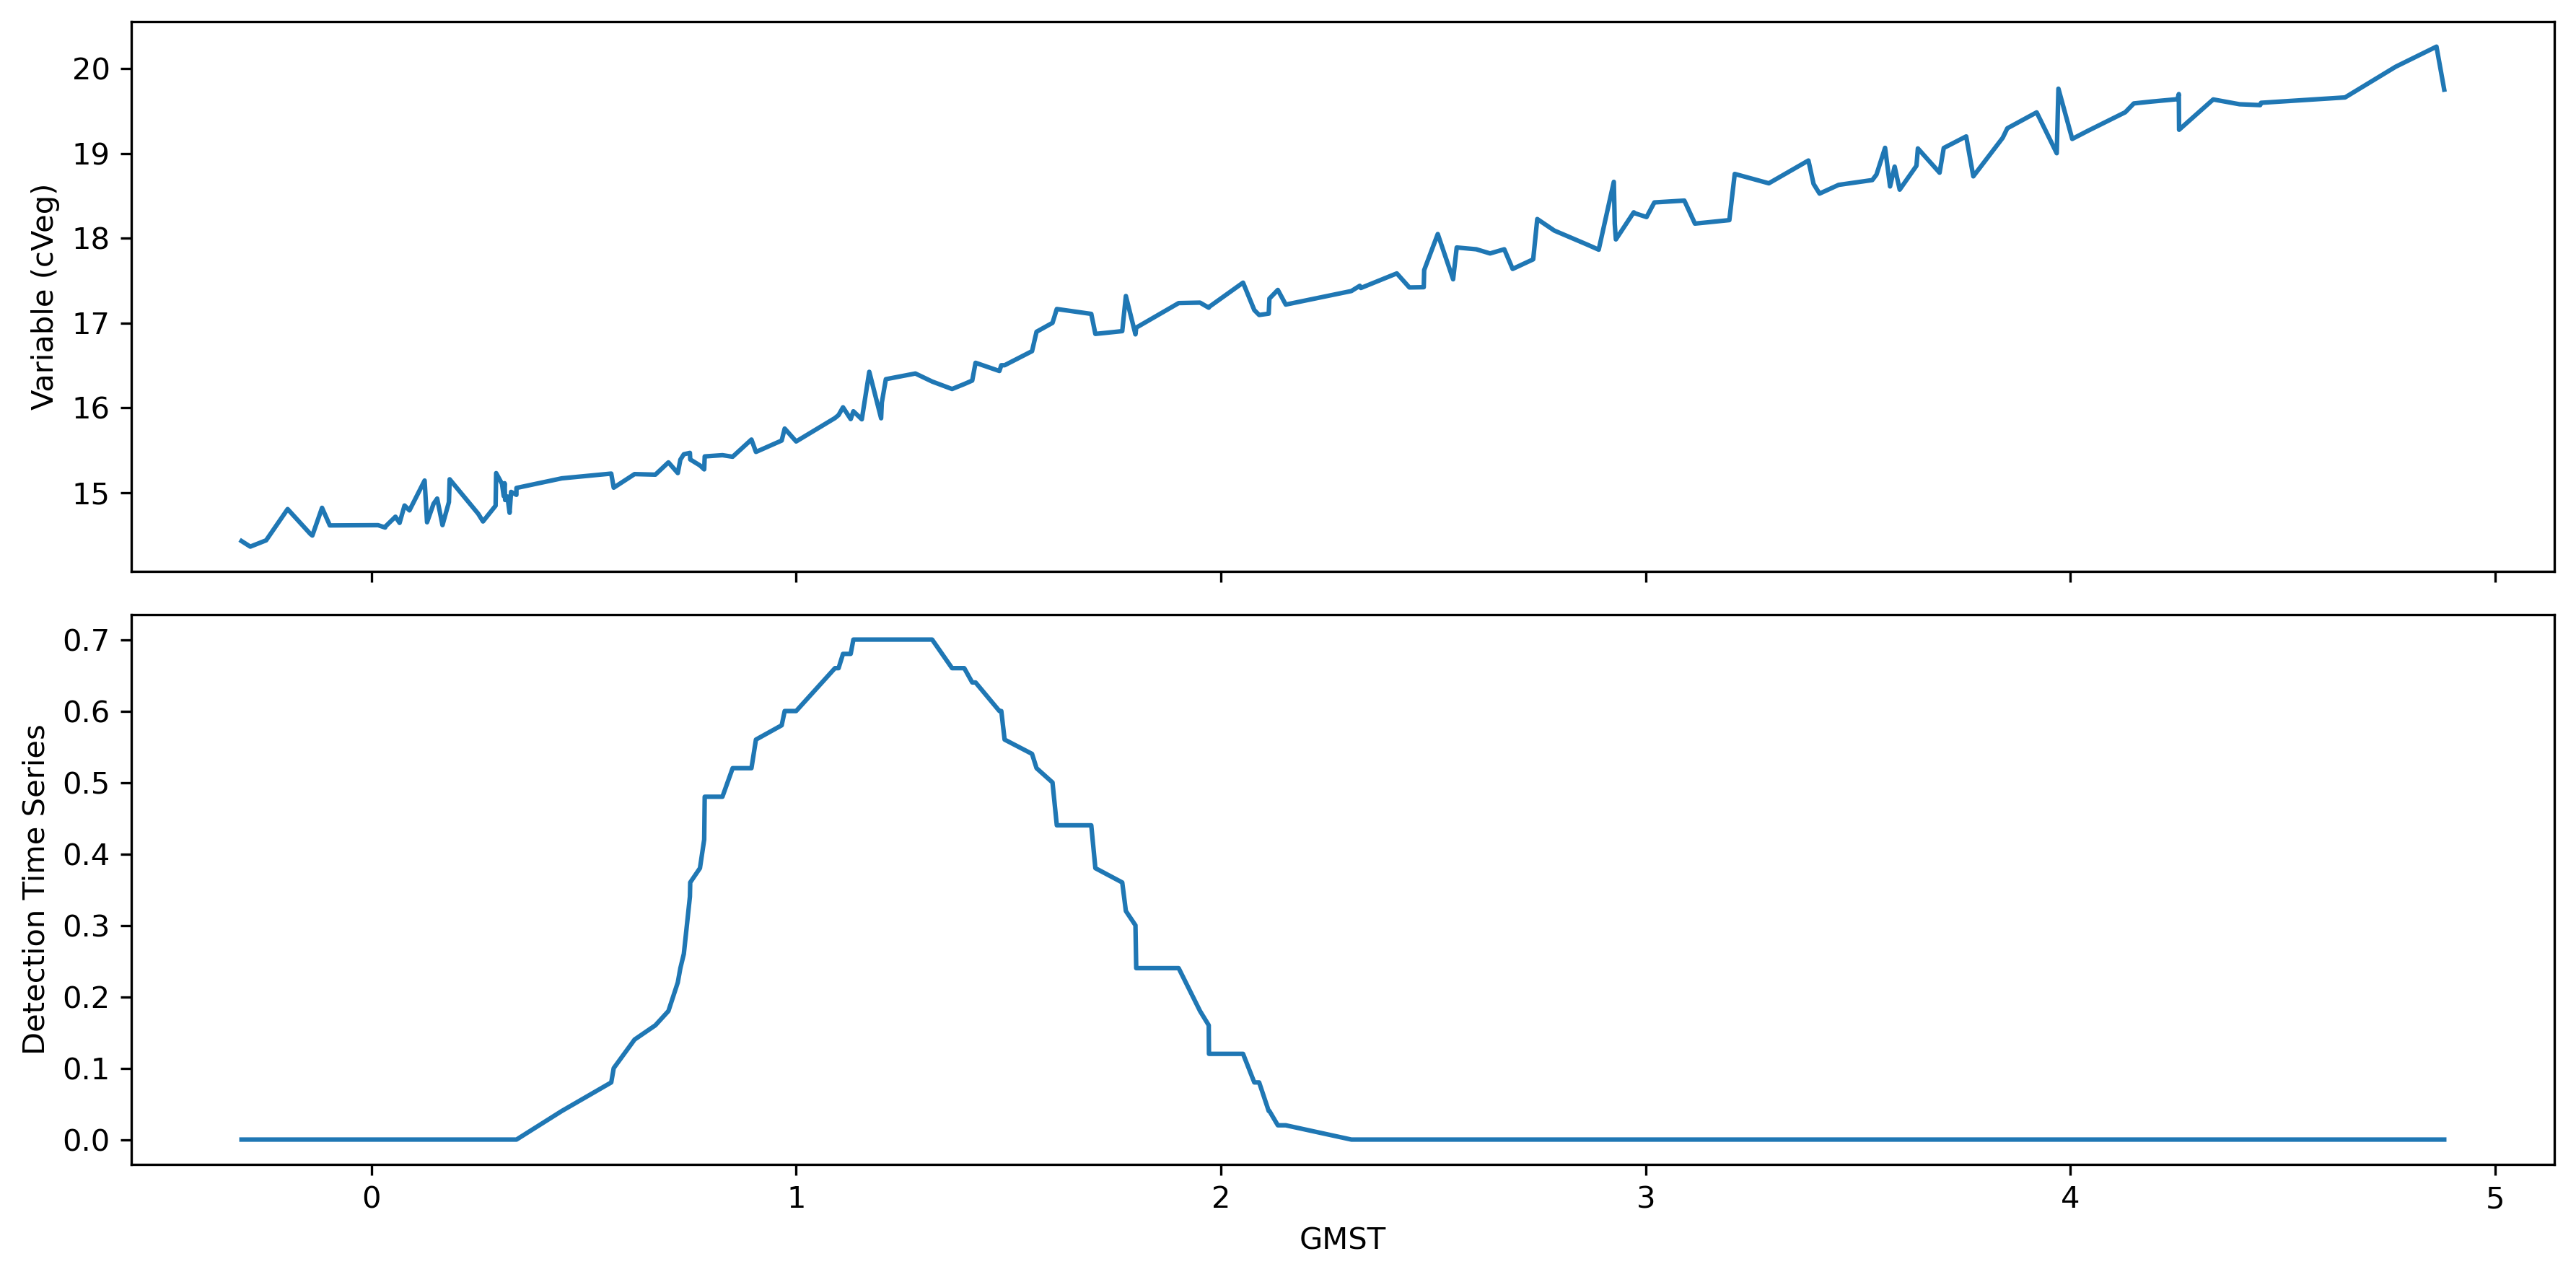

In [68]:
fig, axs = plt.subplots(2, sharex=True)
idx, idy = 3, 10

td.data.cVeg.isel(x=idx, y=idy).plot(ax=axs[0])
td.data.cVeg_dts.isel(x=idx, y=idy).plot(ax=axs[1])
axs[0].set_ylabel("Variable (cVeg)")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

In [69]:
from sklearn.cluster import HDBSCAN

td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    var="cVeg",  # reference your base variable, TOAD will find computed shifts for this variable
    method=HDBSCAN(min_cluster_size=10),
    time_weight=1.0,
)

INFO: New cluster variable cVeg_dts_cluster: Identified 0 clusters in 28 pts; Left 100.0% as noise (28 pts).



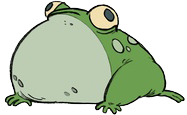

In [70]:
td

In [71]:
# You can find all method parameters used for the computation in the attributes, e.g:
td.data.cVeg_dts.attrs

{'standard_name': 'vegetation_carbon_content',
 'long_name': 'Carbon Mass in Vegetation',
 'comment': 'Carbon mass per unit area in vegetation.',
 'units': 'kg m-2',
 'original_name': 'TOTVEGC',
 'cell_methods': 'area: mean where land time: mean',
 'cell_measures': 'area: areacella',
 'history': "2019-09-27T13:48:49Z altered by CMOR: Converted type from 'd' to 'f'.",
 'time_dim': 'GMST',
 'method_name': 'ASDETECT',
 'toad_version': '1.0.7',
 'base_variable': 'cVeg',
 'variable_type': 'shift',
 'shifts_ignore_nan_warnings': 'False',
 'shifts_lmin': '5',
 'shifts_segmentation': 'two_sided',
 'shifts_timescale': '(0.5, 1.0)'}

In [72]:
td.plot.overview();